# Importación de librerías:
## pandas: importación y manipulacióde datos
## numpy: calculos numericos y operacion con arrays multidimensionales
## matplotlib.pyplot: visualización de gráficos
## seaborn: visualización estadística avanzada basada en matplotlib
## torch: creación y entrenamiento de redes neuronales
## train_test_split: divide los datos en entrenamiento y validación
## labelEncoder: codificación de etiquetas categóricas a numéricas
## classification_report: reporte detallado de métricas
## accuracy_score, f1_score, precision_score, recall_score, confusion_matrix: metricas 
## RobertaTokenizerFast: tokenizacion de texto para el modelo RoBERTa
## RobertaForSequenceClassification: modelo RoBERTa preentrenado adaptado para clasificación.
## rrainer: entrenamiento y evaluación de modelos de Hugging Face
## trainingArguments: Configuración de hiperparámetros para el entrenamiento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import RobertaTokenizerFast

In [2]:
data = pd.read_csv("reviews_22052025_2400.csv")

In [3]:
data.rename(columns={'classification': 'Cluster'}, inplace=True)

# Se convierte Genuine en 1 y Fake en 0

In [4]:
data['Cluster'] = data['Cluster'].replace({'Genuine': 1, 'Fake': 0}).astype(int)
print(data['Cluster'].unique())

[1 0]


# Se crea un dataset solo con las columnas text y Cluster

In [5]:
columnas = ['text', 'Cluster']
df = data[columnas].copy()

In [6]:
print("--- Verificando DataFrame 'df' antes del finetuning ---")
print("Shape del df:", df.shape)
print("Columnas del df:", df.columns.tolist())
print("Primeras filas del df:\n", df.head())
print("-" * 30)

# Verificación de columnas necesarias
if 'Cluster' not in df.columns:
    raise ValueError("El DataFrame 'df' (después de la transformación) debe contener una columna llamada 'Cluster'.")
if 'text' not in df.columns:
     raise ValueError("El DataFrame 'df' (después de la transformación) debe contener una columna llamada 'text'.")


--- Verificando DataFrame 'df' antes del finetuning ---
Shape del df: (1850, 2)
Columnas del df: ['text', 'Cluster']
Primeras filas del df:
                                                 text  Cluster
0  I needed an honest mechanic with good communic...        1
1  It's Arby's and it's finally open!  They've on...        1
2  The Westshore Grand, A Tribute Portfolio Hotel...        0
3  The worst pedi ever! \nWorst mani ever \nI nee...        1
4  Food was outstanding and the employees are so ...        0
------------------------------


# Conversion de etiquetas a número
## se transforma los valores de Cluster a valores númericos

In [7]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Cluster'])

In [8]:
num_labels = len(label_encoder.classes_)
class_names = [str(c) for c in label_encoder.classes_]  # Aseguramos que las clases sean cadenas
print(f"\nNúmero de clases (clusters) encontradas: {num_labels}")
print(f"Clases originales y su mapeo a enteros: {list(zip(class_names, range(num_labels)))}")


Número de clases (clusters) encontradas: 2
Clases originales y su mapeo a enteros: [('0', 0), ('1', 1)]


In [9]:
min_test_size_required = num_labels
test_size_val = max(min_test_size_required, int(len(df) * 0.2))

if len(df) - test_size_val < num_labels:
    raise ValueError(f"Dataset demasiado pequeño ({len(df)} filas) para una división estratificada con {num_labels} clases. "
                     f"El set de entrenamiento ({len(df) - test_size_val}) debe tener al menos {num_labels} muestras.")

print(f"Usando tamaño de validación (filas): {test_size_val}")

Usando tamaño de validación (filas): 370


# Division de datos en entrenamiento y validación

In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=test_size_val,
    random_state=42,
    stratify=df['label']
)

print(f"Tamaño del conjunto de entrenamiento: {len(train_df)}")
print(f"Tamaño del conjunto de validación: {len(val_df)}")

Tamaño del conjunto de entrenamiento: 1480
Tamaño del conjunto de validación: 370


# Se carga el tokenzaro de roberta-base

In [11]:
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
max_length = 350

# Se crea un dataset compatible con PyTorch

In [12]:
class TextClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [13]:
train_dataset = TextClassificationDataset(train_df['text'], train_df['label'], tokenizer, max_length)
val_dataset = TextClassificationDataset(val_df['text'], val_df['label'], tokenizer, max_length)

# Se carga el modelo RoBERTa 

In [14]:
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=num_labels)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
output_dir = "./roberta_finetuned_clusters"

# Se define los parametros del entrenamiento

In [16]:
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    report_to="none"
)

In [17]:
output_dir = "./roberta_finetuned_clusters"

# Se definen las metricas

In [18]:
def compute_metrics(p):
    pred = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    f1 = f1_score(labels, pred, average='weighted')
    acc = accuracy_score(labels, pred)
    return {"accuracy": acc, "f1": f1}

# Se entrena el modelo

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\omen\AppData\Local\Temp\ipykernel_2372\2721217396.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [20]:
print("\nIniciando entrenamiento...")
trainer.train()
print("Entrenamiento finalizado.")
print("\nEvaluando el modelo en el conjunto de validación final y generando reportes...")


Iniciando entrenamiento...


Step,Training Loss
10,0.711800
20,0.703400
30,0.682200
40,0.708200
50,0.705400
60,0.685900
70,0.700700
80,0.686300
90,0.676800
100,0.696800


Entrenamiento finalizado.

Evaluando el modelo en el conjunto de validación final y generando reportes...


# Evaluacion del modelo

In [21]:
predictions = trainer.predict(val_dataset)

# Obtención de las etiquetas 

In [22]:
true_labels_indices = predictions.label_ids
predicted_labels_indices = np.argmax(predictions.predictions, axis=1)

# Impresión de metricas


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       196
           1       0.66      0.76      0.70       174

    accuracy                           0.70       370
   macro avg       0.70      0.70      0.70       370
weighted avg       0.71      0.70      0.70       370


Calculando la Matriz de Confusión...

Matriz de Confusión (Filas = Verdadero, Columnas = Predicho):

     0    1
0  127   69
1   42  132


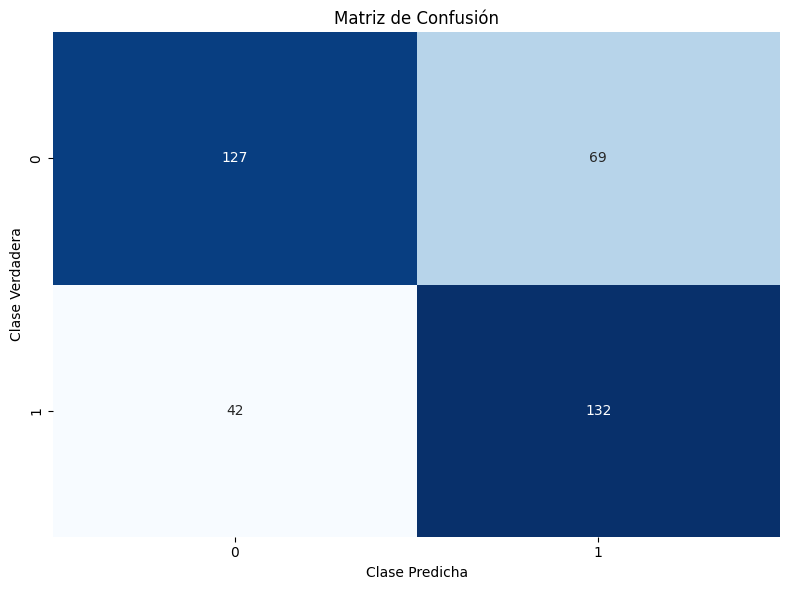


Ejemplo de predicciones vs etiquetas verdaderas:


In [23]:
print("\nReporte de Clasificación:")
report = classification_report(true_labels_indices, predicted_labels_indices, target_names=class_names)
print(report)
print("\nCalculando la Matriz de Confusión...")
cm = confusion_matrix(true_labels_indices, predicted_labels_indices)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nMatriz de Confusión (Filas = Verdadero, Columnas = Predicho):\n")
print(cm_df)
if num_labels > 1:
    plt.figure(figsize=(max(8, num_labels), max(6, num_labels * 0.8)))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Matriz de Confusión')
    plt.ylabel('Clase Verdadera')
    plt.xlabel('Clase Predicha')
    plt.tight_layout()
    plt.show()
print("\nEjemplo de predicciones vs etiquetas verdaderas:")
predicted_clusters = label_encoder.inverse_transform(predicted_labels_indices)
true_clusters = label_encoder.inverse_transform(true_labels_indices)

val_texts = val_df['text'].reset_index(drop=True)
val_true_labels = val_df['Cluster'].reset_index(drop=True)
